# Descriptive Analysis â€” Airbnb Global Listings

This notebook applies **K-Means Clustering** to segment listings by location, price, and property features.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

In [ ]:
# Load cleaned dataset
df = pd.read_csv("../../data/airbnb-cleaned.csv")
print(f"Cleaned data shape: {df.shape}")

Cleaned data shape: (494954, 162)
Raw data shape: (494954, 89)


---
## Part 1 â€” K-Means Clustering

We segment listings into groups based on **location** (Latitude, Longitude), **price**, and key **property features** (Accommodates, Bedrooms, Bathrooms, Review Scores Rating).

Steps:
1. Select and standardise features
2. Use the **Elbow Method** and **Silhouette Score** to choose optimal *K*
3. Fit K-Means and visualise clusters

In [4]:
# 1.1 â€” Feature selection & standardisation
cluster_features = [
    "Latitude", "Longitude", "Price",
    "Accommodates", "Bedrooms", "Bathrooms",
    "Review Scores Rating"
]

X_cluster = df[cluster_features].copy()
print("Clustering features shape:", X_cluster.shape)
print(X_cluster.describe().round(2))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

Clustering features shape: (494954, 7)
        Latitude  Longitude      Price  Accommodates   Bedrooms  Bathrooms  \
count  494954.00  494954.00  494954.00     494954.00  494954.00  494954.00   
mean       38.04     -15.02     136.40          3.31       1.38       1.25   
std        22.94      70.36     143.86          2.09       0.94       0.61   
min       -38.22    -123.22      20.00          1.00       0.00       0.00   
25%        38.91     -73.97      55.00          2.00       1.00       1.00   
50%        42.31       2.14      90.00          2.00       1.00       1.00   
75%        51.38      12.44     150.00          4.00       2.00       1.00   
max        55.99     153.64     801.00         21.00      96.00      10.00   

       Review Scores Rating  
count             494954.00  
mean                  93.45  
std                    7.41  
min                   20.00  
25%                   92.00  
50%                   95.00  
75%                   98.00  
max               

In [5]:
# 1.2 â€” Elbow Method & Silhouette Score
# Use a sample for speed (full dataset is ~495k rows)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=30000, replace=False)
X_sample = X_scaled[sample_idx]

K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f"K={k:2d}  |  Inertia={km.inertia_:>12,.0f}  |  Silhouette={sil:.4f}")

K= 2  |  Inertia=     160,003  |  Silhouette=0.4012
K= 3  |  Inertia=     122,483  |  Silhouette=0.4444
K= 4  |  Inertia=     107,648  |  Silhouette=0.4469
K= 5  |  Inertia=      93,436  |  Silhouette=0.3708
K= 6  |  Inertia=      81,919  |  Silhouette=0.3389
K= 7  |  Inertia=      72,704  |  Silhouette=0.2954
K= 8  |  Inertia=      68,119  |  Silhouette=0.2956
K= 9  |  Inertia=      63,877  |  Silhouette=0.2956
K=10  |  Inertia=      60,296  |  Silhouette=0.2993


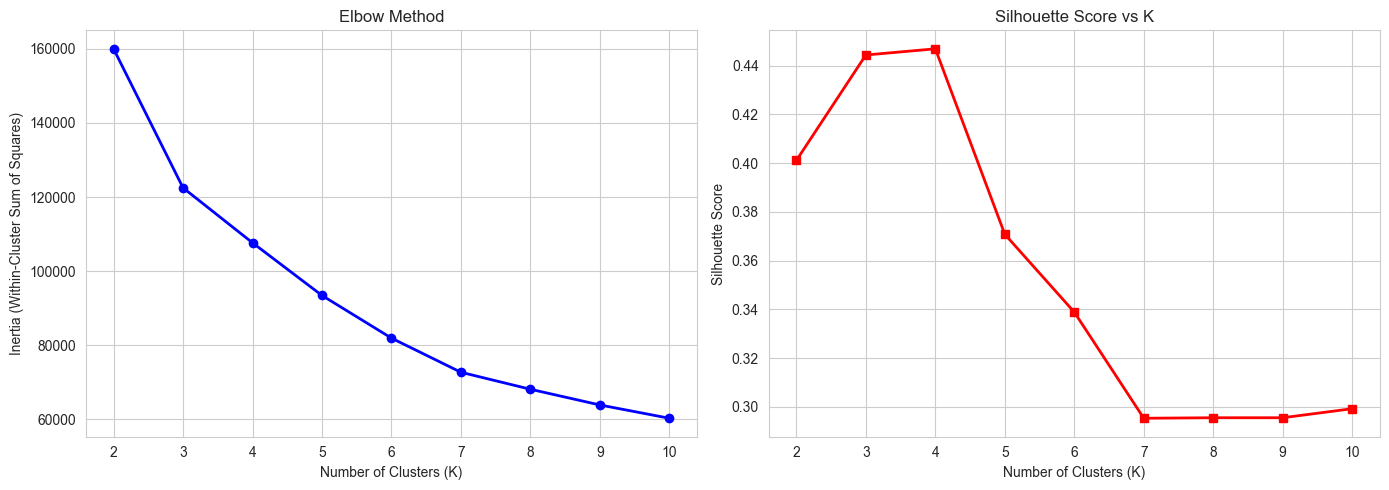


Best K by silhouette score: 4


In [6]:
# 1.3 â€” Visualise Elbow & Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, "bo-", linewidth=2)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)")
axes[0].set_title("Elbow Method")
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, silhouettes, "rs-", linewidth=2)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig("../../docs/kmeans_elbow_silhouette.png", bbox_inches="tight")
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"\nBest K by silhouette score: {best_k}")

In [7]:
# 1.4 â€” Fit final K-Means on the full dataset
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df["Cluster"] = kmeans_final.fit_predict(X_scaled)

print(f"K-Means fitted with K={best_k}")
print("\nCluster sizes:")
print(df["Cluster"].value_counts().sort_index())

K-Means fitted with K=4

Cluster sizes:
Cluster
0     70780
1     44634
2    336748
3     42792
Name: count, dtype: int64


In [8]:
# 1.5 â€” Cluster profiles (mean of key features per cluster)
profile_cols = ["Price", "Latitude", "Longitude", "Accommodates",
                "Bedrooms", "Bathrooms", "Review Scores Rating",
                "Number of Reviews", "Cleaning Fee"]
cluster_profile = df.groupby("Cluster")[profile_cols].mean().round(2)
print("Cluster Profiles:")
cluster_profile

Cluster Profiles:


,Price,Latitude,Longitude,Accommodates,Bedrooms,Bathrooms,Review Scores Rating,Number of Reviews,Cleaning Fee
Cluster,,,,,,,,,
0,281.66,41.09,-32.16,6.77,2.96,2.15,94.59,13.46,96.82
1,98.60,44.98,-16.35,3.04,1.15,1.12,76.56,14.83,42.51
2,105.12,45.11,-31.70,2.66,1.07,1.08,95.36,18.26,43.76
3,181.68,-29.89,145.99,3.01,1.40,1.23,94.15,12.18,64.13


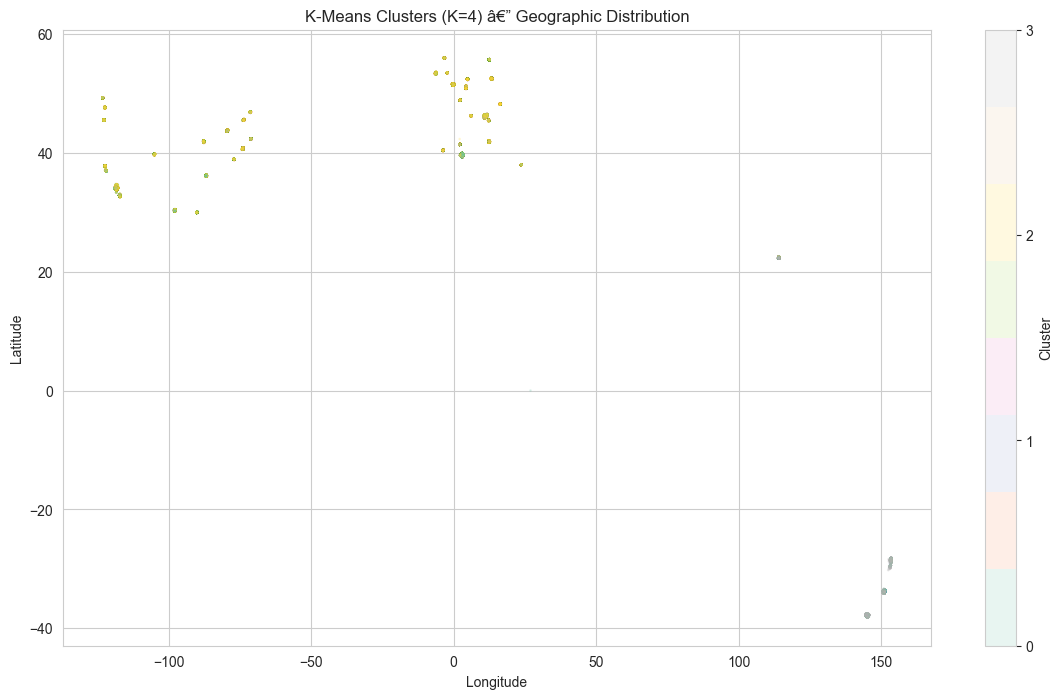

In [9]:
# 1.6 â€” Geographic scatter plot of clusters
fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(
    df["Longitude"], df["Latitude"],
    c=df["Cluster"], cmap="Set2", alpha=0.15, s=1
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"K-Means Clusters (K={best_k}) â€” Geographic Distribution")
plt.colorbar(scatter, ax=ax, label="Cluster", ticks=range(best_k))
plt.savefig("../../docs/kmeans_geo_clusters.png", bbox_inches="tight")
plt.show()

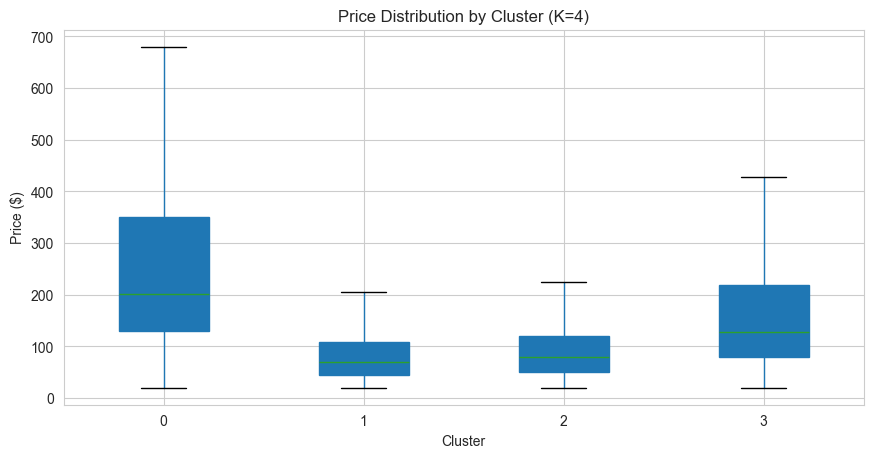

In [10]:
# 1.7 â€” Price distribution per cluster (boxplot)
fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column="Price", by="Cluster", ax=ax,
           showfliers=False, patch_artist=True)
ax.set_title(f"Price Distribution by Cluster (K={best_k})")
ax.set_xlabel("Cluster")
ax.set_ylabel("Price ($)")
plt.suptitle("")
plt.savefig("../../docs/kmeans_price_by_cluster.png", bbox_inches="tight")
plt.show()

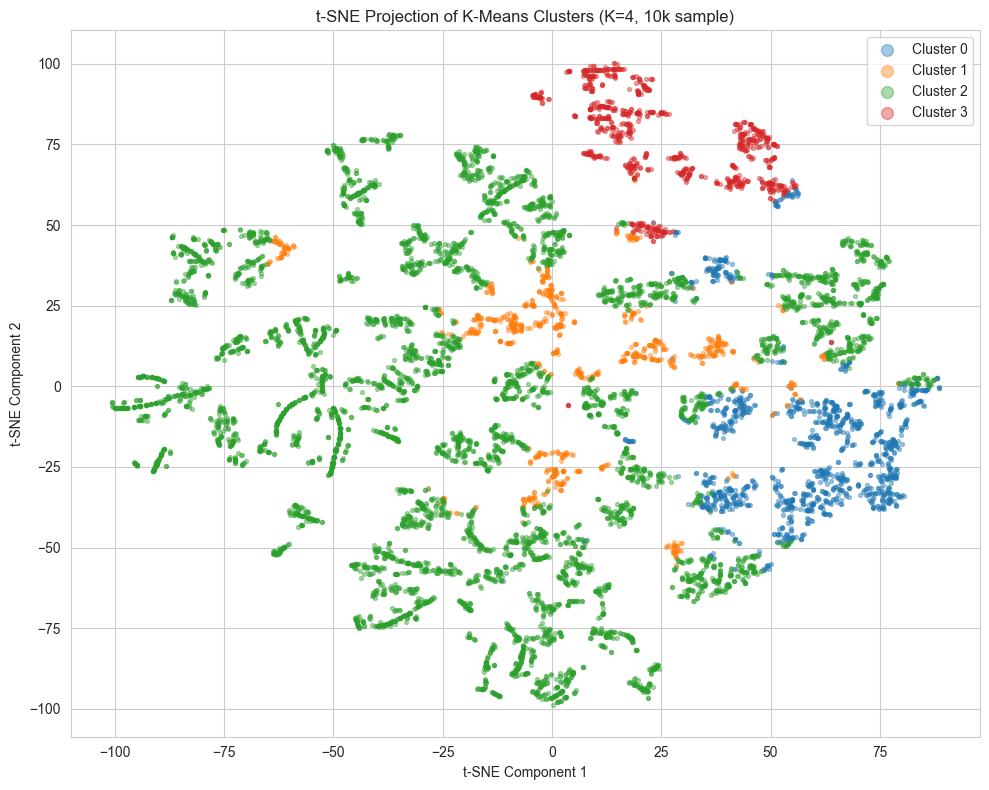

t-SNE preserves local neighborhood structure:
  - Well-separated blobs → clusters are distinct in feature space
  - Overlapping regions → ambiguous boundary points


In [11]:
# 1.8 — t-SNE Visualization of Clusters
from sklearn.manifold import TSNE

# Use a sample (t-SNE is O(n²) — too slow for 495k)
np.random.seed(42)
tsne_sample_idx = np.random.choice(len(X_scaled), size=10000, replace=False)
X_tsne_input = X_scaled[tsne_sample_idx]
labels_tsne = df["Cluster"].values[tsne_sample_idx]

# Fit t-SNE (reduce 7D → 2D)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne_2d = tsne.fit_transform(X_tsne_input)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
for k in range(best_k):
    mask = labels_tsne == k
    ax.scatter(X_tsne_2d[mask, 0], X_tsne_2d[mask, 1],
               alpha=0.4, s=8, label=f"Cluster {k}")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_title(f"t-SNE Projection of K-Means Clusters (K={best_k}, 10k sample)")
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig("../../docs/kmeans_tsne.png", bbox_inches="tight")
plt.show()

print("t-SNE preserves local neighborhood structure:")
print("  - Well-separated blobs → clusters are distinct in feature space")
print("  - Overlapping regions → ambiguous boundary points")

---
## Summary

### K-Means Clustering
- Listings were segmented using location, price, and property features
- The optimal number of clusters was selected via the Elbow Method and Silhouette Score
- Clusters reveal distinct geographic and pricing segments (e.g., budget vs. premium areas)